In [4]:



import pandas as pd

import matplotlib.pyplot as plt


path = '/Users/sasha/Documents/GitHub/shopping-behavior/data/processed/shopping_cleaned.csv'
df = pd.read_csv(path)

df.head()

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    3158 non-null   float64
 1   Gender                 3158 non-null   object 
 2   Item Purchased         3158 non-null   object 
 3   Purchase Amount (USD)  3158 non-null   float64
 4   Location               3158 non-null   object 
 5   Size                   3158 non-null   object 
 6   Color                  3158 non-null   object 
 7   Season                 3158 non-null   object 
 8   Review Rating          3158 non-null   object 
 9   Shipping Type          3158 non-null   object 
 10  Promo Code Used        3158 non-null   object 
 11  Previous Purchases     3158 non-null   int64  
 12  Payment Method         3158 non-null   object 
dtypes: float64(2), int64(1), object(10)
memory usage: 320.9+ KB


,Age,Purchase Amount (USD),Previous Purchases
count,3158.000000,3158.000000,3158.000000
mean,34.185244,38.812750,5.860988
std,10.578195,11.525595,5.844408
min,18.000000,11.946095,0.000000
25%,26.000000,29.419108,1.000000
50%,33.000000,37.126663,4.000000
75%,41.000000,48.974363,9.000000
max,73.000000,68.327455,20.000000


In [9]:
import pandas as pd
path = '/Users/sasha/Documents/GitHub/shopping-behavior/data/processed/shopping_cleaned.csv'
df = pd.read_csv(path)
print(df.columns)
#1. What are the most popular colors by season?
print("\n--- Popular Colors by Season ---")
print(df.groupby('Season')['Color'].value_counts().groupby(level=0).head(1))

#2. What is the most popular clothing item by season?
print("\n--- Popular Items by Season ---")
print(df.groupby('Season')['Item Purchased'].value_counts().groupby(level=0).head(1))

#3. What is the effect of promo codes on the dollar amount of purchases?
print("\n--- Effect of Promo Codes ---")
print(df.groupby('Promo Code Used')['Purchase Amount (USD)'].mean())
#4. When do users leave a review?
print("\n--- Reviews by Season ---")
print(df.groupby('Season')['Review Rating'].count())

Index(['Age', 'Gender', 'Item Purchased', 'Purchase Amount (USD)', 'Location',
       'Size', 'Color', 'Season', 'Review Rating', 'Shipping Type',
       'Promo Code Used', 'Previous Purchases', 'Payment Method'],
      dtype='object')

--- Popular Colors by Season ---
Season  Color    
Fall    Brown         97
Spring  Baby blue     69
Summer  Lavender     102
Winter  Black        124
Name: count, dtype: int64

--- Popular Items by Season ---
Season  Item Purchased
Fall    Backpack           72
Spring  Running Shoes      89
Summer  Shorts            152
Winter  Leggings          118
Name: count, dtype: int64

--- Effect of Promo Codes ---
Promo Code Used
No     30.155751
Yes    50.067480
Name: Purchase Amount (USD), dtype: float64

--- Reviews by Season ---
Season
Fall       872
Spring     477
Summer     765
Winter    1044
Name: Review Rating, dtype: int64


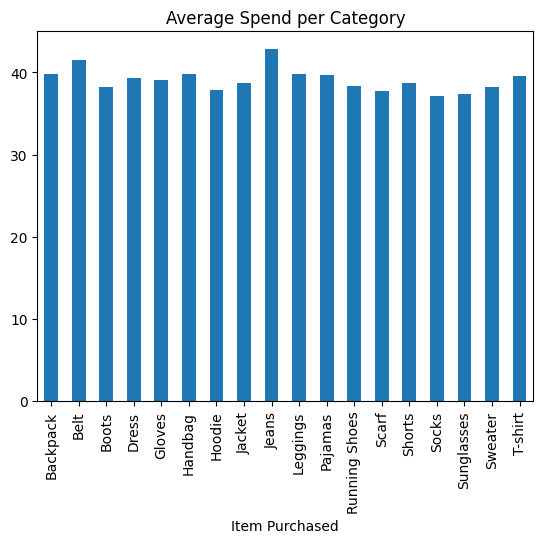

In [ ]:
#1.Average Purchase by Category
df.columns = df.columns.str.strip()
avg_spend = df.groupby('Item Purchased')['Purchase Amount (USD)'].mean()
avg_spend.plot(kind='bar', title='Average Spend per Category')
plt.show()
# Findings: Ths shows which categories are the most expensive on average. it helps the store konw which items bring in the most money per sale.
#for exapmle , in the the Jeans is the highest and the lowest is the socks.

In [ ]:
#2. Payment Method by Gender
pay_map = df.pivot_table(index='Payment Method', columns='Gender', aggfunc='size')
print(pay_map)
# Findings: this table highlights if one gender prefers cash over credit cards. This helps the store decide which payment technolgy to update first.

Gender          Female   Male  Non-binary
Payment Method                           
Bank Transfer      6.0    4.0         NaN
Cash               5.0    4.0         NaN
Credit Card      560.0  571.0         8.0
Debit Card       518.0  515.0        10.0
PayPal           245.0  248.0         3.0
Venmo            216.0  237.0         8.0


In [ ]:
#3. High Spender Preferences
high_spenders = df[df['Purchase Amount (USD)'] > 50]
print(high_spenders['Item Purchased'].value_counts())
# Findings: High spenders usually buy specific items like 'Running Shoes' or 'Handbags'. We should keep these items in stock to keep our best customers happy.

Item Purchased
Running Shoes    57
Handbag          55
Sunglasses       52
T-shirt          51
Shorts           49
Backpack         48
Leggings         47
Dress            47
Gloves           41
Pajamas          39
Sweater          37
Jacket           31
Hoodie           30
Scarf            28
Socks            28
Boots            25
Jeans            10
Belt              7
Name: count, dtype: int64


In [ ]:
#4.how many previous purchases customers had when they used a promo code
sub_freq = df.groupby('Promo Code Used')['Previous Purchases'].value_counts()
print(sub_freq)
# Findings: This table shows how many previous purchases customers had when they used a promo code. It helps us understand if promo codes are attracting new customers or rewarding loyal ones. For example, if most promo code users have few previous purchases, it suggests that the codes are effective in bringing in new customers.

Promo Code Used  Previous Purchases
No               0                     290
                 1                     220
                 2                     173
                 3                     148
                 4                     122
                 20                    110
                 5                     103
                 7                      90
                 6                      88
                 8                      71
                 10                     62
                 9                      59
                 11                     54
                 12                     37
                 13                     36
                 14                     26
                 15                     22
                 16                     22
                 17                     19
                 18                     18
                 19                     15
Yes              0                     225
                 1

In [ ]:
import sys
!{sys.executable} -m pip install pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 10.8 MB 3.6 MB/s eta 0:00:01
     |████████████████████████████████| 510 kB 12.6 MB/s eta 0:00:01
     |████████████████████████████████| 349 kB 17.9 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
